# Respiratory Disease Diagnosis — Descriptive Statistics

Unified summary of `synthetic_medical_symptoms_dataset.csv`: data types, measurement levels, counts, central tendency, spread, skewness, and IQR outliers.

In [21]:
import pandas as pd
import numpy as np
from scipy import stats

df_raw = pd.read_csv("synthetic_medical_symptoms_dataset.csv")
print(f"Original shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

# One-hot encode gender and diagnosis before compiling statistics
df = pd.get_dummies(df_raw, columns=["gender", "diagnosis"], dtype=int)
print(f"Encoded shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.filter(regex=r"^(gender_|diagnosis_)").head()

Original shape: 3,000 rows × 24 columns
Encoded shape: 3,000 rows × 29 columns


,gender_Female,gender_Male,diagnosis_COVID-19,diagnosis_Dengue,diagnosis_Influenza,diagnosis_Malaria,diagnosis_Pneumonia
0,1,0,0,1,0,0,0
1,0,1,0,1,0,0,0
2,1,0,0,0,1,0,0
3,1,0,1,0,0,0,0
4,1,0,0,1,0,0,0


## Unified Summary Table

`gender` and `diagnosis` are one-hot encoded above (0/1 indicator columns). One row per column. Skew and IQR outliers are computed only for **interval** and **ratio** columns—not for nominal or ordinal features.

In [ ]:
measurement_levels = {
    "age": "ratio",
    "fever": "ordinal",
    "cough": "ordinal",
    "fatigue": "ordinal",
    "headache": "ordinal",
    "muscle_pain": "ordinal",
    "nausea": "ordinal",
    "vomiting": "ordinal",
    "diarrhea": "ordinal",
    "skin_rash": "ordinal",
    "loss_smell": "ordinal",
    "loss_taste": "ordinal",
    "systolic_bp": "ratio",
    "diastolic_bp": "ratio",
    "heart_rate": "ratio",
    "temperature_c": "interval",
    "oxygen_saturation": "ratio",
    "wbc_count": "ratio",
    "hemoglobin": "ratio",
    "platelet_count": "ratio",
    "crp_level": "ratio",
    "glucose_level": "ratio",
}

# One-hot encoded columns are binary nominal indicators
for col in df.columns:
    if col.startswith("gender_") or col.startswith("diagnosis_"):
        measurement_levels[col] = "nominal"


def column_mode(series: pd.Series):
    modes = series.mode(dropna=True)
    return modes.iloc[0] if len(modes) else np.nan


def iqr_outlier_count(series: pd.Series) -> int:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())


rows = []
for col in df.columns:
    s = df[col]
    is_numeric = pd.api.types.is_numeric_dtype(s)
    level = measurement_levels[col]
    distribution_stats = level in {"interval", "ratio"}

    rows.append({
        "column": col,
        "data_type": str(s.dtype),
        "measurement_level": level,
        "count": s.count(),
        "missing": s.isna().sum(),
        "unique_values": s.nunique(),
        "mean": s.mean() if is_numeric else np.nan,
        "median": s.median() if is_numeric else np.nan,
        "mode": column_mode(s),
        "min": s.min() if is_numeric else np.nan,
        "max": s.max() if is_numeric else np.nan,
        "range": (s.max() - s.min()) if is_numeric else np.nan,
        "skew": stats.skew(s.dropna(), bias=False) if distribution_stats else np.nan,
        "iqr_outlier_count": iqr_outlier_count(s) if distribution_stats else np.nan,
    })

unified_summary = pd.DataFrame(rows).set_index("column")

for c in ["mean", "median", "min", "max", "range", "skew"]:
    unified_summary[c] = unified_summary[c].round(3)

unified_summary["iqr_outlier_count"] = unified_summary["iqr_outlier_count"].astype("Int64")

unified_summary

,data_type,measurement_level,count,missing,unique_values,mean,median,mode,min,max,range,skew,iqr_outlier_count
column,,,,,,,,,,,,,
age,int64,ratio,3000,0,89,43.678,43.00,60.00,1.00,89.00,88.00,0.072,0
fever,int64,ordinal,3000,0,4,1.077,1.00,0.00,0.00,3.00,3.00,NaN,<NA>
cough,int64,ordinal,3000,0,4,1.058,1.00,0.00,0.00,3.00,3.00,NaN,<NA>
fatigue,int64,ordinal,3000,0,4,1.117,1.00,0.00,0.00,3.00,3.00,NaN,<NA>
headache,int64,ordinal,3000,0,4,1.103,1.00,0.00,0.00,3.00,3.00,NaN,<NA>
muscle_pain,int64,ordinal,3000,0,4,1.125,1.00,0.00,0.00,3.00,3.00,NaN,<NA>
nausea,int64,ordinal,3000,0,4,1.131,1.00,0.00,0.00,3.00,3.00,NaN,<NA>
vomiting,int64,ordinal,3000,0,4,1.142,1.00,0.00,0.00,3.00,3.00,NaN,<NA>
diarrhea,int64,ordinal,3000,0,4,1.085,1.00,0.00,0.00,3.00,3.00,NaN,<NA>


## Summary Plots

Visual overview of diagnosis distribution, patient age (split by gender), and body temperature.

C:\Users\tnewman\AppData\Local\Temp\ipykernel_11780\126211045.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax_age_box.boxplot(
C:\Users\tnewman\AppData\Local\Temp\ipykernel_11780\126211045.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


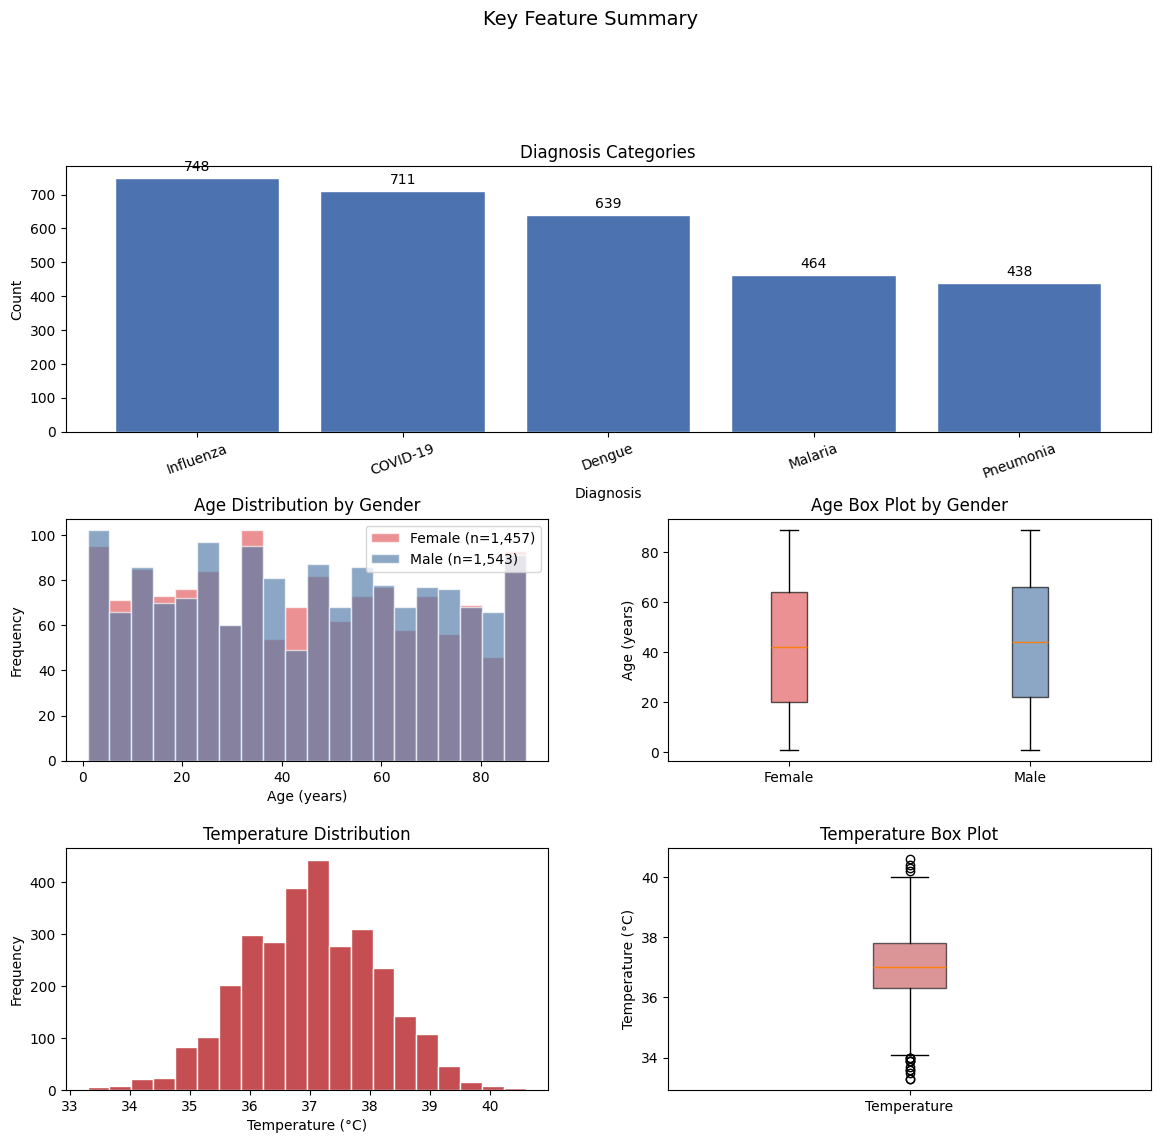

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 12))
grid = fig.add_gridspec(3, 2, height_ratios=[1.1, 1, 1], hspace=0.35, wspace=0.25)

# Diagnosis categories
ax_diag = fig.add_subplot(grid[0, :])
diagnosis_counts = df_raw["diagnosis"].value_counts().sort_values(ascending=False)
bars = ax_diag.bar(diagnosis_counts.index, diagnosis_counts.values, color="#4C72B0", edgecolor="white")
ax_diag.set_title("Diagnosis Categories")
ax_diag.set_xlabel("Diagnosis")
ax_diag.set_ylabel("Count")
ax_diag.bar_label(bars, padding=3)
ax_diag.tick_params(axis="x", rotation=20)

# Age distribution by gender
gender_colors = {"Female": "#E15759", "Male": "#4E79A7"}
ax_age_hist = fig.add_subplot(grid[1, 0])
for gender in ["Female", "Male"]:
    ages = df_raw.loc[df_raw["gender"] == gender, "age"]
    ax_age_hist.hist(
        ages,
        bins=20,
        alpha=0.65,
        label=f"{gender} (n={len(ages):,})",
        color=gender_colors[gender],
        edgecolor="white",
    )
ax_age_hist.set_title("Age Distribution by Gender")
ax_age_hist.set_xlabel("Age (years)")
ax_age_hist.set_ylabel("Frequency")
ax_age_hist.legend()

# Age box plot by gender
ax_age_box = fig.add_subplot(grid[1, 1])
age_by_gender = [
    df_raw.loc[df_raw["gender"] == gender, "age"].dropna()
    for gender in ["Female", "Male"]
]
box = ax_age_box.boxplot(
    age_by_gender,
    labels=["Female", "Male"],
    patch_artist=True,
    vert=True,
)
for patch, gender in zip(box["boxes"], ["Female", "Male"]):
    patch.set_facecolor(gender_colors[gender])
    patch.set_alpha(0.65)
ax_age_box.set_title("Age Box Plot by Gender")
ax_age_box.set_ylabel("Age (years)")

# Temperature distribution
ax_temp_hist = fig.add_subplot(grid[2, 0])
ax_temp_hist.hist(df_raw["temperature_c"], bins=20, color="#C44E52", edgecolor="white")
ax_temp_hist.set_title("Temperature Distribution")
ax_temp_hist.set_xlabel("Temperature (°C)")
ax_temp_hist.set_ylabel("Frequency")

# Temperature box plot
ax_temp_box = fig.add_subplot(grid[2, 1])
ax_temp_box.boxplot(df_raw["temperature_c"], vert=True, patch_artist=True,
                    boxprops={"facecolor": "#C44E52", "alpha": 0.6})
ax_temp_box.set_title("Temperature Box Plot")
ax_temp_box.set_ylabel("Temperature (°C)")
ax_temp_box.set_xticklabels(["Temperature"])

plt.suptitle("Key Feature Summary", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()